# Загрузка библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import ast

from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier

In [840]:
plt.rcParams['figure.figsize'] = (8, 5)  # 800x500 px
plt.rcParams['figure.dpi'] = 100

# Отключаем автоматическое масштабирование в Jupyter
%config InlineBackend.figure_format = 'retina'  # или 'png'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

## Вспомогательные функции

In [841]:
def log(msg):
    """Печать с timestamp"""
    print(f"[{datetime.now():%H:%M:%S}] {msg}")

In [ ]:
def log_experiment(model_name, params, train_score, val_score, features_info="", log_file='experiments_log.csv'):
    """
    Сохраняет результаты эксперимента в CSV файл
    """
    result = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model': model_name,
        'train_bal_acc': train_score,
        'val_bal_acc': val_score,
        'gap': train_score - val_score,
        'params': str(params),
        'features': features_info
    }
    
    if os.path.exists(log_file):
        df_log = pd.read_csv(log_file)
        df_log = pd.concat([df_log, pd.DataFrame([result])], ignore_index=True)
    else:
        df_log = pd.DataFrame([result])
    
    df_log.to_csv(log_file, index=False)
    
    print(f"Результат сохранён в {log_file}")
    print(df_log.sort_values('val_bal_acc', ascending=False).to_string(index=False))
    
    return df_log

In [843]:
def visualize_experiments(csv_path='experiments_log.csv'):
    """
    Визуализирует все эксперименты из CSV файла.
    """
    # ═══════════════════════════════════════════════════════════════
    # ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
    # ═══════════════════════════════════════════════════════════════
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Файл '{csv_path}' не найден!")
        return None
    
    if len(df) == 0:
        print("Файл пустой, нет экспериментов для визуализации.")
        return df
    
    # Парсим timestamp и параметры
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['exp_num'] = range(1, len(df) + 1)
    
    def parse_params(p):
        try:
            return ast.literal_eval(p) if pd.notna(p) else {}
        except:
            return {}
    
    df['params_dict'] = df['params'].fillna('').apply(parse_params)
    df['depth'] = df['params_dict'].apply(lambda x: x.get('depth'))
    df['learning_rate'] = df['params_dict'].apply(lambda x: x.get('learning_rate'))
    df['iterations'] = df['params_dict'].apply(lambda x: x.get('iterations'))
    df['l2_leaf_reg'] = df['params_dict'].apply(lambda x: x.get('l2_leaf_reg'))
    
    print(f"Загружено экспериментов: {len(df)}")
    if 'val_bal_acc' in df.columns:
        best_idx = df['val_bal_acc'].idxmax()
        print(f"Лучший val_bal_acc: {df.loc[best_idx, 'val_bal_acc']:.4f} (Эксперимент #{best_idx + 1})")
    print("=" * 70)
    
    # ══════════════════════════════════════════════════════════════
    # ГРАФИК: ПРОГРЕСС ВО ВРЕМЕНИ
    # ═══════════════════════════════════════════════════════════════
    if 'train_bal_acc' in df.columns and 'val_bal_acc' in df.columns:
        fig, ax = plt.subplots()
        
        ax.plot(df['exp_num'], df['train_bal_acc'], 'o-', label='Train BalAcc', 
                color='skyblue', linewidth=2.5, markersize=8)
        ax.plot(df['exp_num'], df['val_bal_acc'], 's-', label='Val BalAcc', 
                color='coral', linewidth=2.5, markersize=8)
        
        # Отмечаем лучший результат
        best = df.loc[best_idx]
        ax.scatter(best['exp_num'], best['val_bal_acc'], 
                   s=300, color='red', marker='*', zorder=5, label=f'Best (#{int(best["exp_num"])})')
        ax.annotate(f"Val: {best['val_bal_acc']:.4f}", 
                    xy=(best['exp_num'], best['val_bal_acc']),
                    xytext=(20, 10), textcoords='offset points',
                    fontsize=11, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red'))
        
        ax.set_xlabel('Номер эксперимента', fontsize=13)
        ax.set_ylabel('Balanced Accuracy', fontsize=13)
        ax.set_title('Прогресс экспериментов во времени', fontsize=15, fontweight='bold')
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(df['exp_num'])
        plt.tight_layout()
        plt.show()
    
    # ═══════════════════════════════════════════════════════════════
    # ГРАФИК: АНАЛИЗ ПЕРЕОБУЧЕНИЯ (GAP)
    # ═══════════════════════════════════════════════════════════════
    if 'gap' in df.columns:
        fig, ax = plt.subplots()
        
        colors = ['green' if g < 0.01 else 'orange' if g < 0.03 else 'red' for g in df['gap']]
        bars = ax.bar(df['exp_num'], df['gap'], color=colors, alpha=0.7, edgecolor='black')
        
        ax.axhline(y=0.01, color='green', linestyle='--', alpha=0.7, label='Отлично (< 1%)')
        ax.axhline(y=0.03, color='orange', linestyle='--', alpha=0.7, label='Нормально (< 3%)')
        ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Переобучение (> 5%)')
        
        for bar, gap in zip(bars, df['gap']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(df['gap']) * 0.02,
                    f"{gap:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Номер эксперимента', fontsize=13)
        ax.set_ylabel('Gap (Train - Val)', fontsize=13)
        ax.set_title('Анализ переобучения (Gap)', fontsize=15, fontweight='bold')
        ax.set_xticks(df['exp_num'])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
    
    # ═══════════════════════════════════════════════════════════════
    # СВОДНАЯ ТАБЛИЦА
    # ═══════════════════════════════════════════════════════════════
    cols_to_show = ['exp_num', 'model', 'depth', 'learning_rate', 'iterations', 
                    'train_bal_acc', 'val_bal_acc', 'gap', 'features']
    cols_to_show = [c for c in cols_to_show if c in df.columns]
    
    summary = df[cols_to_show].copy()
    summary.columns = ['#', 'Model', 'Depth', 'LR', 'Iters', 'Train', 'Val', 'Gap', 'Features']
    
    print("\nСводная таблица экспериментов:")
    
    if 'val_bal_acc' in df.columns:
        # Форматируем числовые колонки для красивого вывода
        display_summary = summary.copy()
        for col in ['Train', 'Val', 'Gap']:
            if col in display_summary.columns:
                display_summary[col] = display_summary[col].apply(
                    lambda x: f"{x:.4f}" if pd.notna(x) else ""
                )
        
        # Добавляем маркер лучшего эксперимента
        best_exp_num = df.loc[best_idx, 'exp_num']
        display_summary['Best'] = display_summary['#'].apply(
            lambda x: "⭐" if x == best_exp_num else ""
        )
        
        # Переупорядочиваем колонки
        cols_order = ['Best', '#', 'Model', 'Depth', 'LR', 'Iters', 'Train', 'Val', 'Gap', 'Features']
        display_summary = display_summary[[c for c in cols_order if c in display_summary.columns]]
        
        # Пытаемся использовать красивый стиль, если jinja2 доступен
        try:
            def highlight_row(row):
                if row['#'] == best_exp_num:
                    return ['background-color: gold; font-weight: bold'] * len(row)
                return [''] * len(row)
            
            styled = display_summary.style.apply(highlight_row, axis=1)
            display(styled)
        except (ImportError, AttributeError):
            # Если jinja2 не установлен, показываем обычную таблицу
            print("(Установите 'pip install jinja2' для красивого форматирования)")
            display(display_summary)
    
    return df

# Загрузка данных

In [862]:
ID_COL = 'id'
TARGET_COL = 'class'
NUMERIC_COLS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
CATEGORICAL_COLS = ['spectral_type', 'galaxy_population']

In [863]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [864]:
display(train_df.shape)
display(test_df.shape)

(577347, 12)

(247435, 11)

In [865]:
display(train_df.head(5))
display(test_df.head(5))

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [866]:
display(train_df.info())
display(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  str    
 10  galaxy_population  247435 non-null  str    
dtypes: float64(8), int64(1), str(2)
memory usage: 20.8 MB


None

In [867]:
display(train_df.describe())
display(test_df.describe())

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


,id,alpha,delta,u,g,r,i,z,redshift
count,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000
mean,701064.000000,181.360629,21.853898,22.442070,21.009837,19.965651,19.381860,19.043151,0.724780
std,71428.476266,96.213374,18.931367,2.019044,1.798633,1.650949,1.581880,1.587103,0.810582
min,577347.000000,0.010959,-17.959259,13.902664,13.374549,10.390731,10.034180,10.632025,-0.009968
25%,639205.500000,132.023953,2.527822,20.978208,19.866076,18.831805,18.314240,17.976477,0.183117
50%,701064.000000,188.559428,21.452023,22.569616,21.469175,20.431512,19.632235,19.196316,0.498598
75%,762922.500000,231.690068,37.061924,23.869689,22.294539,21.165467,20.618391,20.167750,0.882659
max,824781.000000,359.999724,79.170436,27.835633,27.173411,25.291984,24.567823,25.700336,7.007179


# Разведочный анализ данных

In [850]:
for column in CATEGORICAL_COLS:
    display(train_df[column].value_counts())

display(train_df[TARGET_COL].value_counts())

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

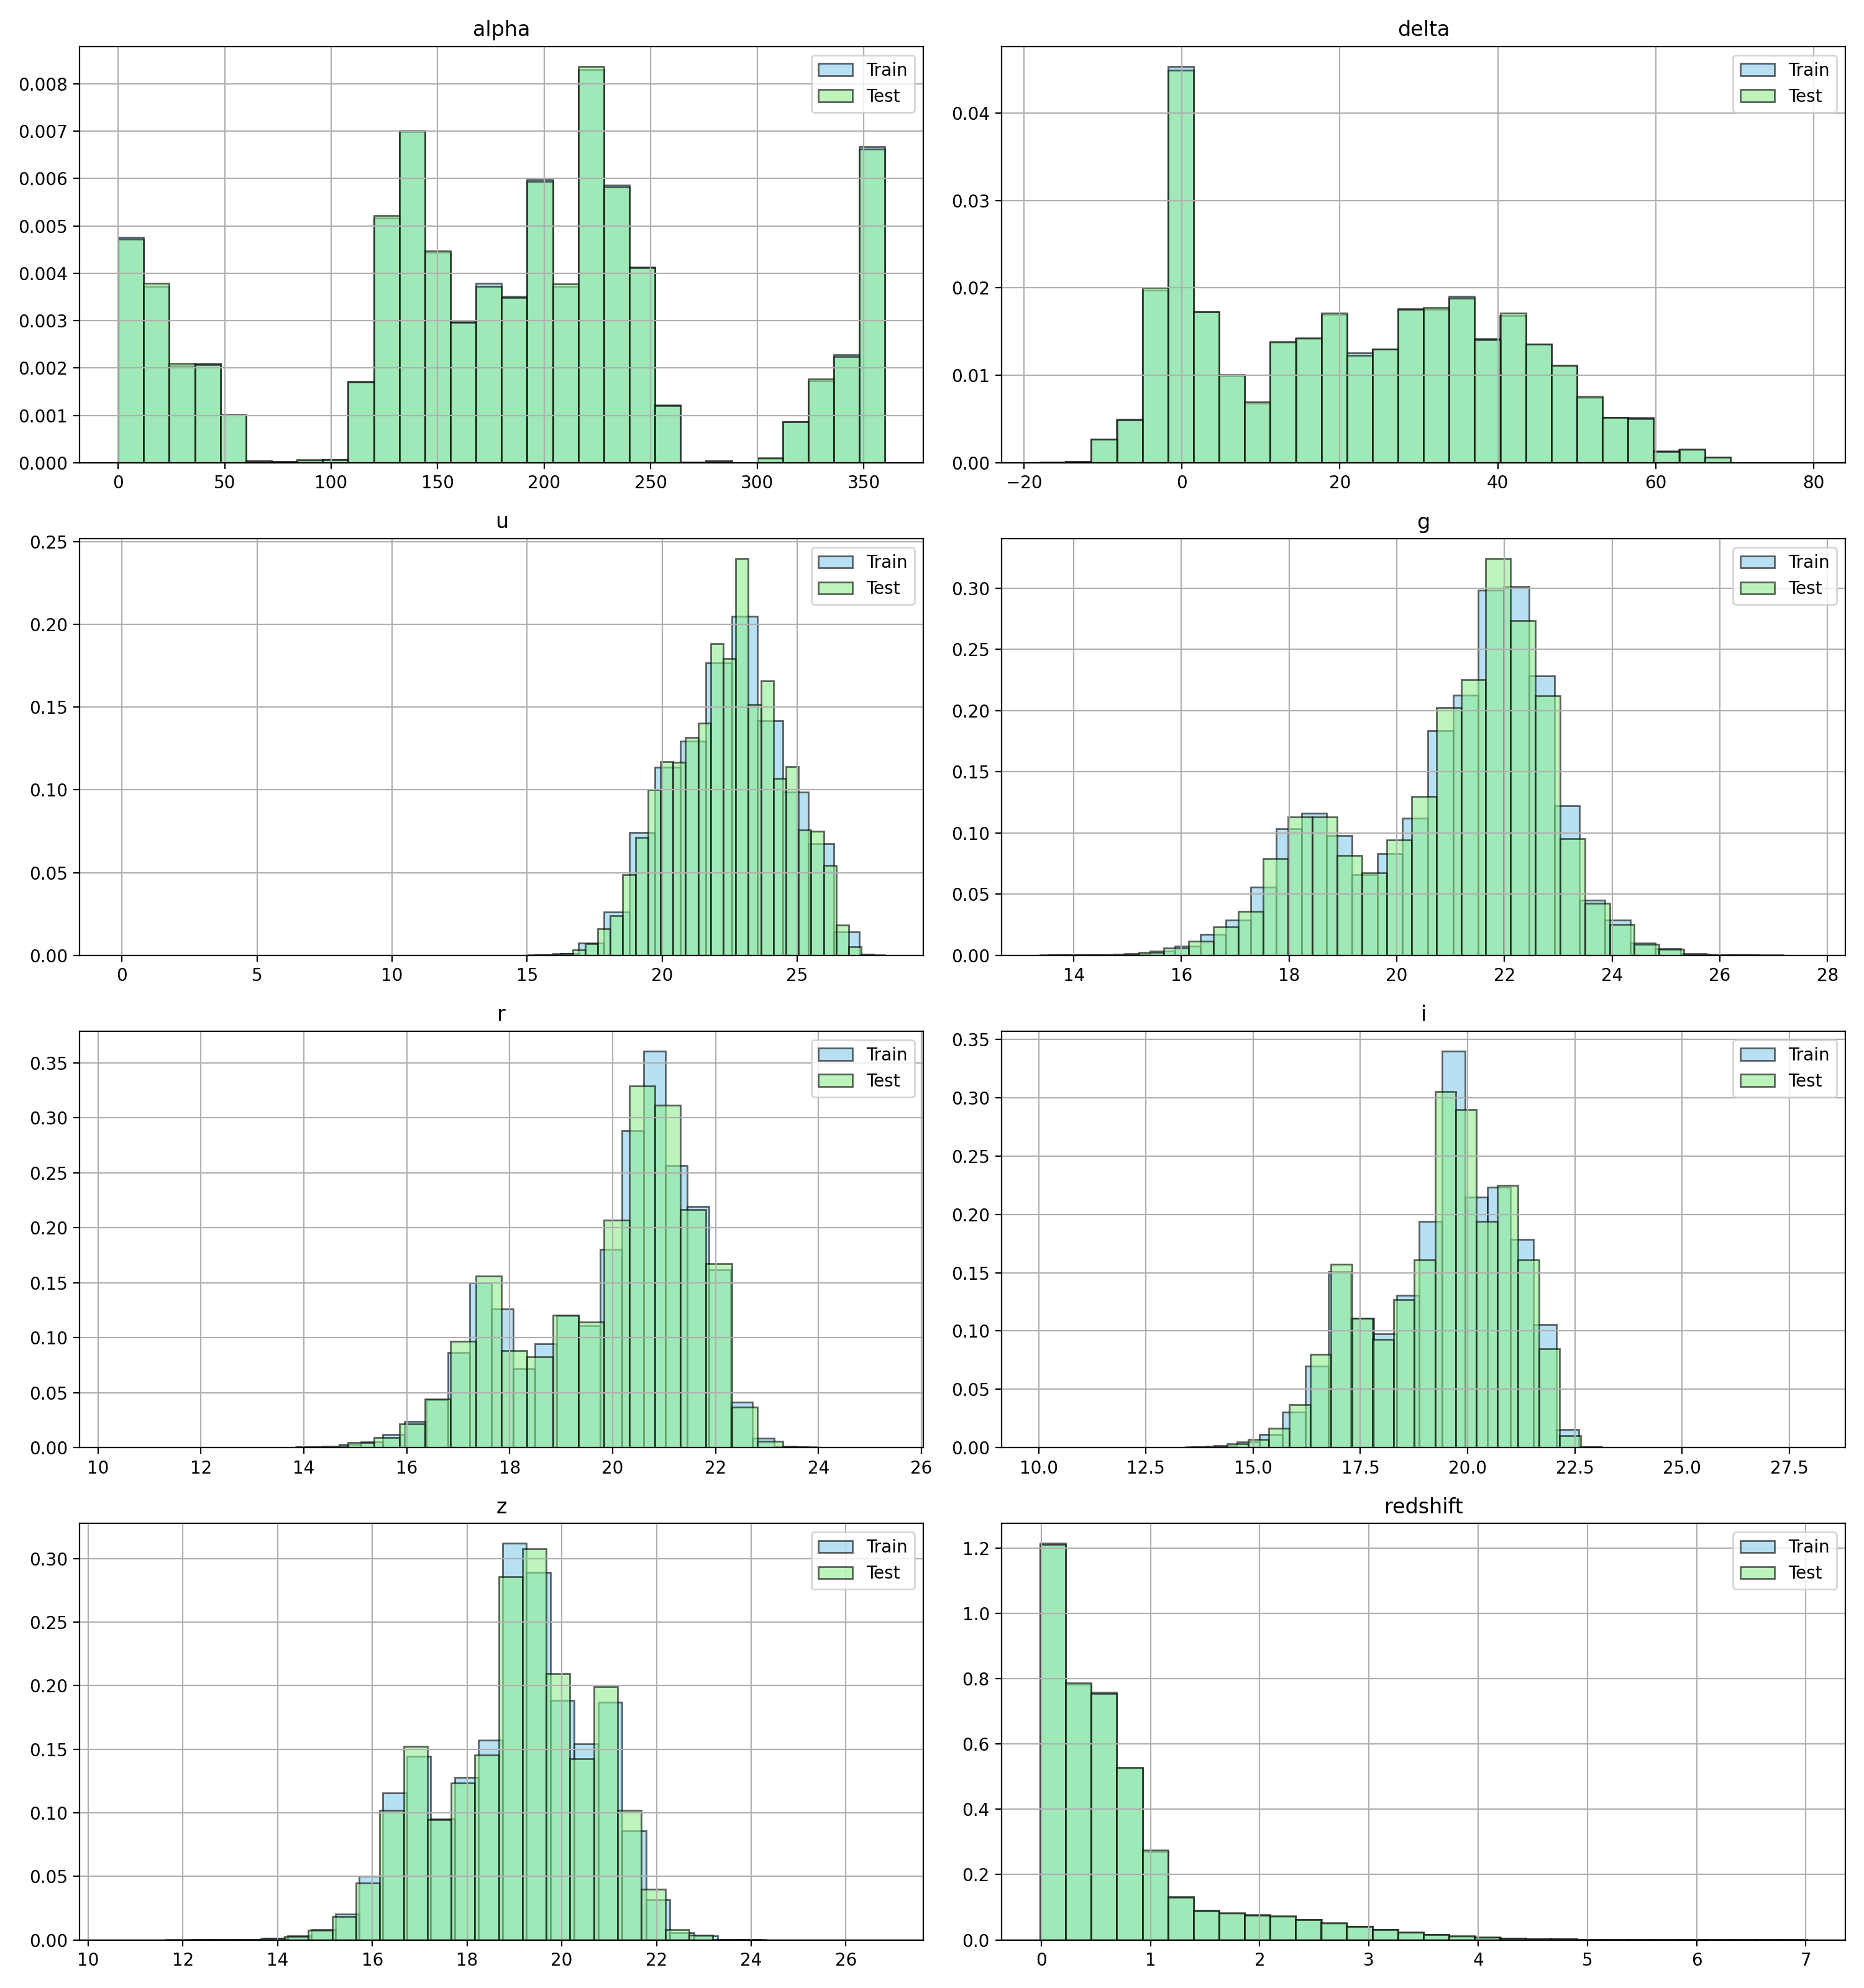

In [851]:
# 1. Оставляем только числовые колонки
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
cols_to_plot = [col for col in numeric_cols if col != 'id']

# 2. Настраиваем сетку для графиков
n_cols = len(cols_to_plot)
ncols = 2  # Количество столбцов в сетке
nrows = int(np.ceil(n_cols / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

# 3. Рисуем гистограммы
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # density=True нормирует гистограмму так, чтобы площадь = 1
    # Теперь по оси Y будет не "количество", а "плотность вероятности"
    train_df[col].hist(ax=ax, bins=30, alpha=0.6, label='Train', color='skyblue', edgecolor='black', density=True)
    test_df[col].hist(ax=ax, bins=30, alpha=0.6, label='Test', color='lightgreen', edgecolor='black', density=True)
    
    ax.set_title(col)
    ax.legend()

# 4. Удаляем пустые графики, если их количество не кратно ncols
for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

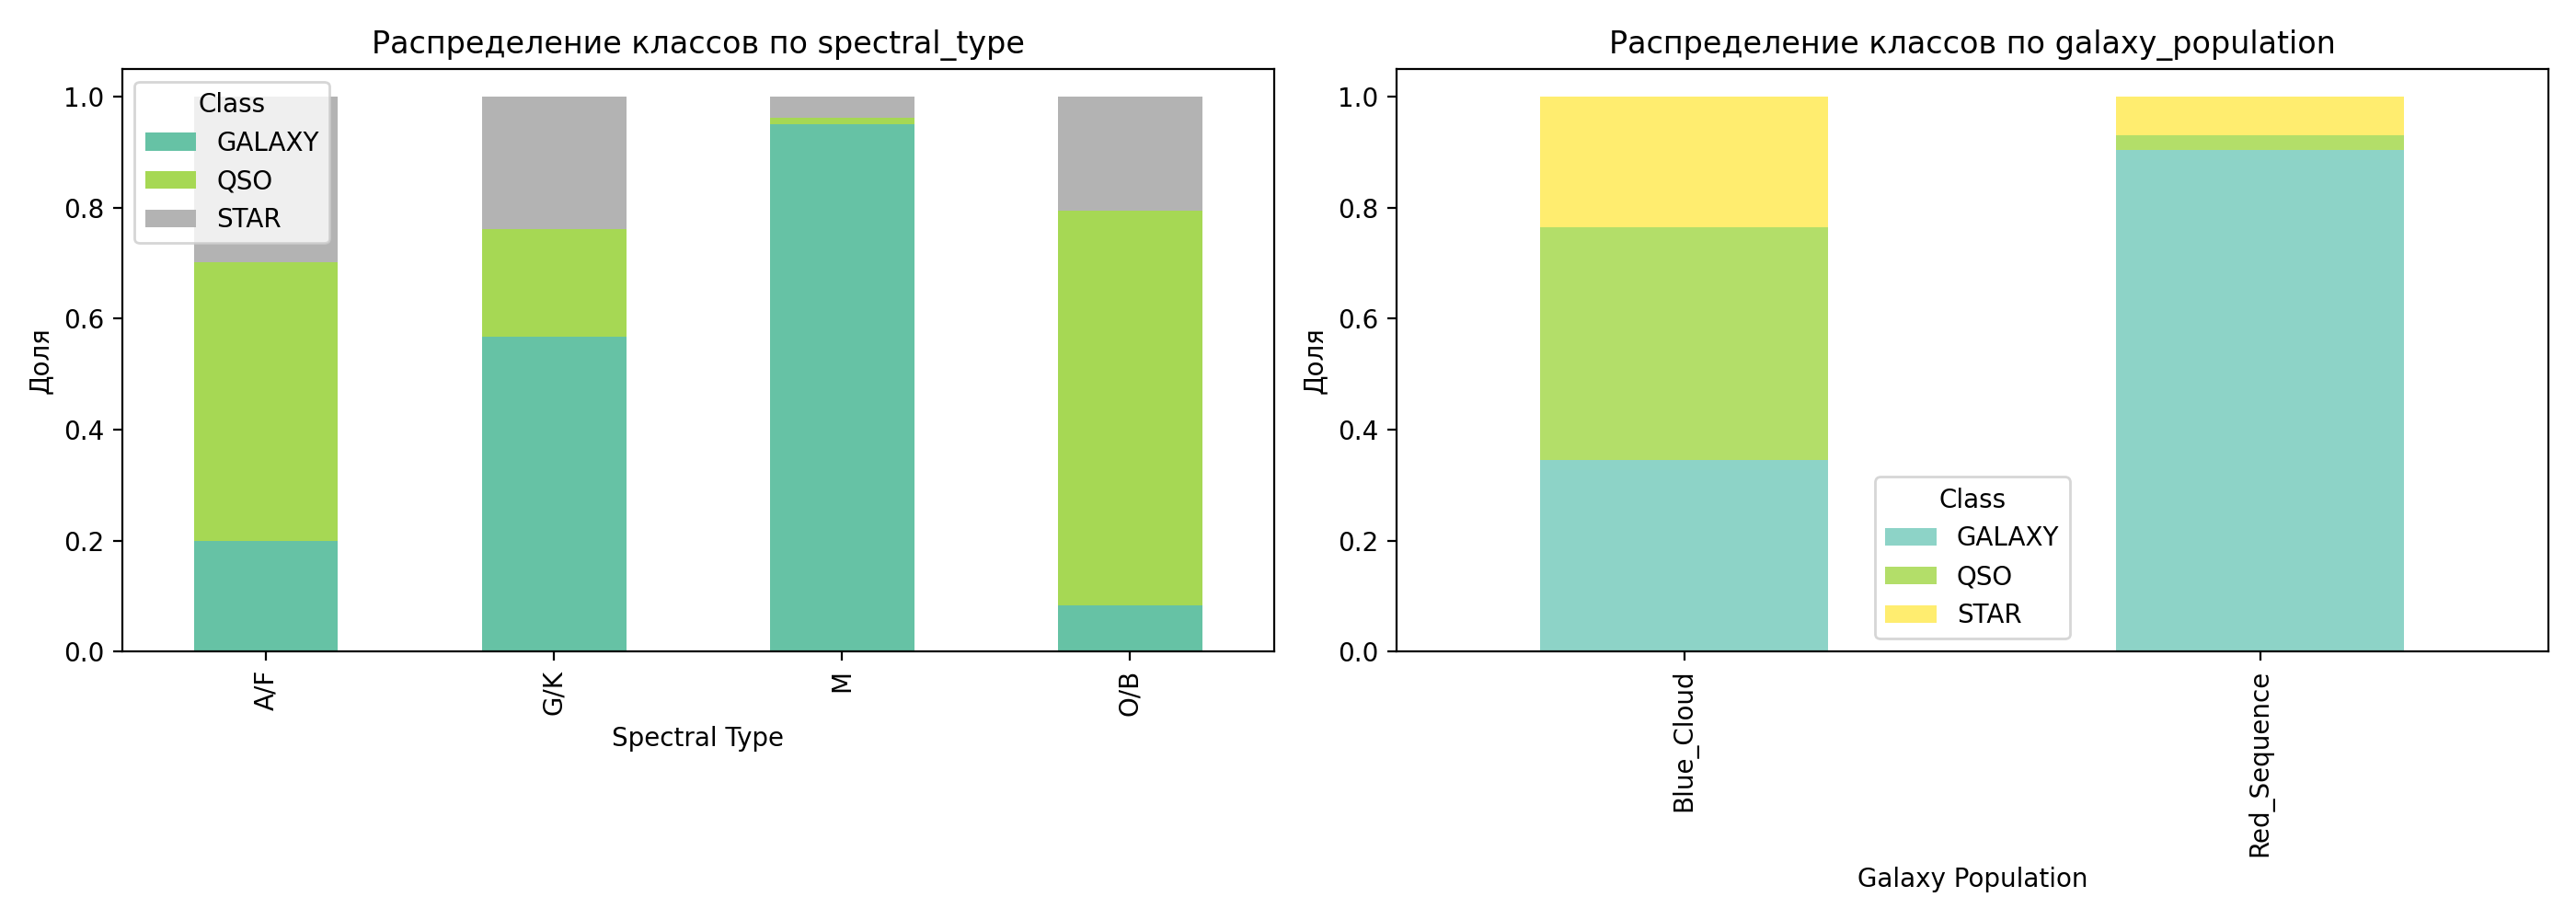

In [852]:
# Считаем долю каждого класса внутри категории
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: spectral_type vs class
pd.crosstab(train_df['spectral_type'], train_df['class'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], colormap='Set2'
)
axes[0].set_title('Распределение классов по spectral_type')
axes[0].set_ylabel('Доля')
axes[0].set_xlabel('Spectral Type')
axes[0].legend(title='Class')

# График 2: galaxy_population vs class
pd.crosstab(train_df['galaxy_population'], train_df['class'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], colormap='Set3'
)
axes[1].set_title('Распределение классов по galaxy_population')
axes[1].set_ylabel('Доля')
axes[1].set_xlabel('Galaxy Population')
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

## Корреляция признаков

### Heatmap корреляции признаков

,alpha,delta,u,g,r,i,z,redshift
alpha,1.000000,0.143541,-0.017242,-0.037731,-0.037830,-0.029333,-0.024583,0.007989
delta,0.143541,1.000000,-0.026860,-0.008386,-0.004395,0.002088,0.003347,0.053763
u,-0.017242,-0.026860,1.000000,0.826880,0.659410,0.521811,0.443923,0.078903
g,-0.037731,-0.008386,0.826880,1.000000,0.912066,0.805020,0.731737,0.237447
r,-0.037830,-0.004395,0.659410,0.912066,1.000000,0.953550,0.913341,0.390989
i,-0.029333,0.002088,0.521811,0.805020,0.953550,1.000000,0.968715,0.466575
z,-0.024583,0.003347,0.443923,0.731737,0.913341,0.968715,1.000000,0.480860
redshift,0.007989,0.053763,0.078903,0.237447,0.390989,0.466575,0.480860,1.000000


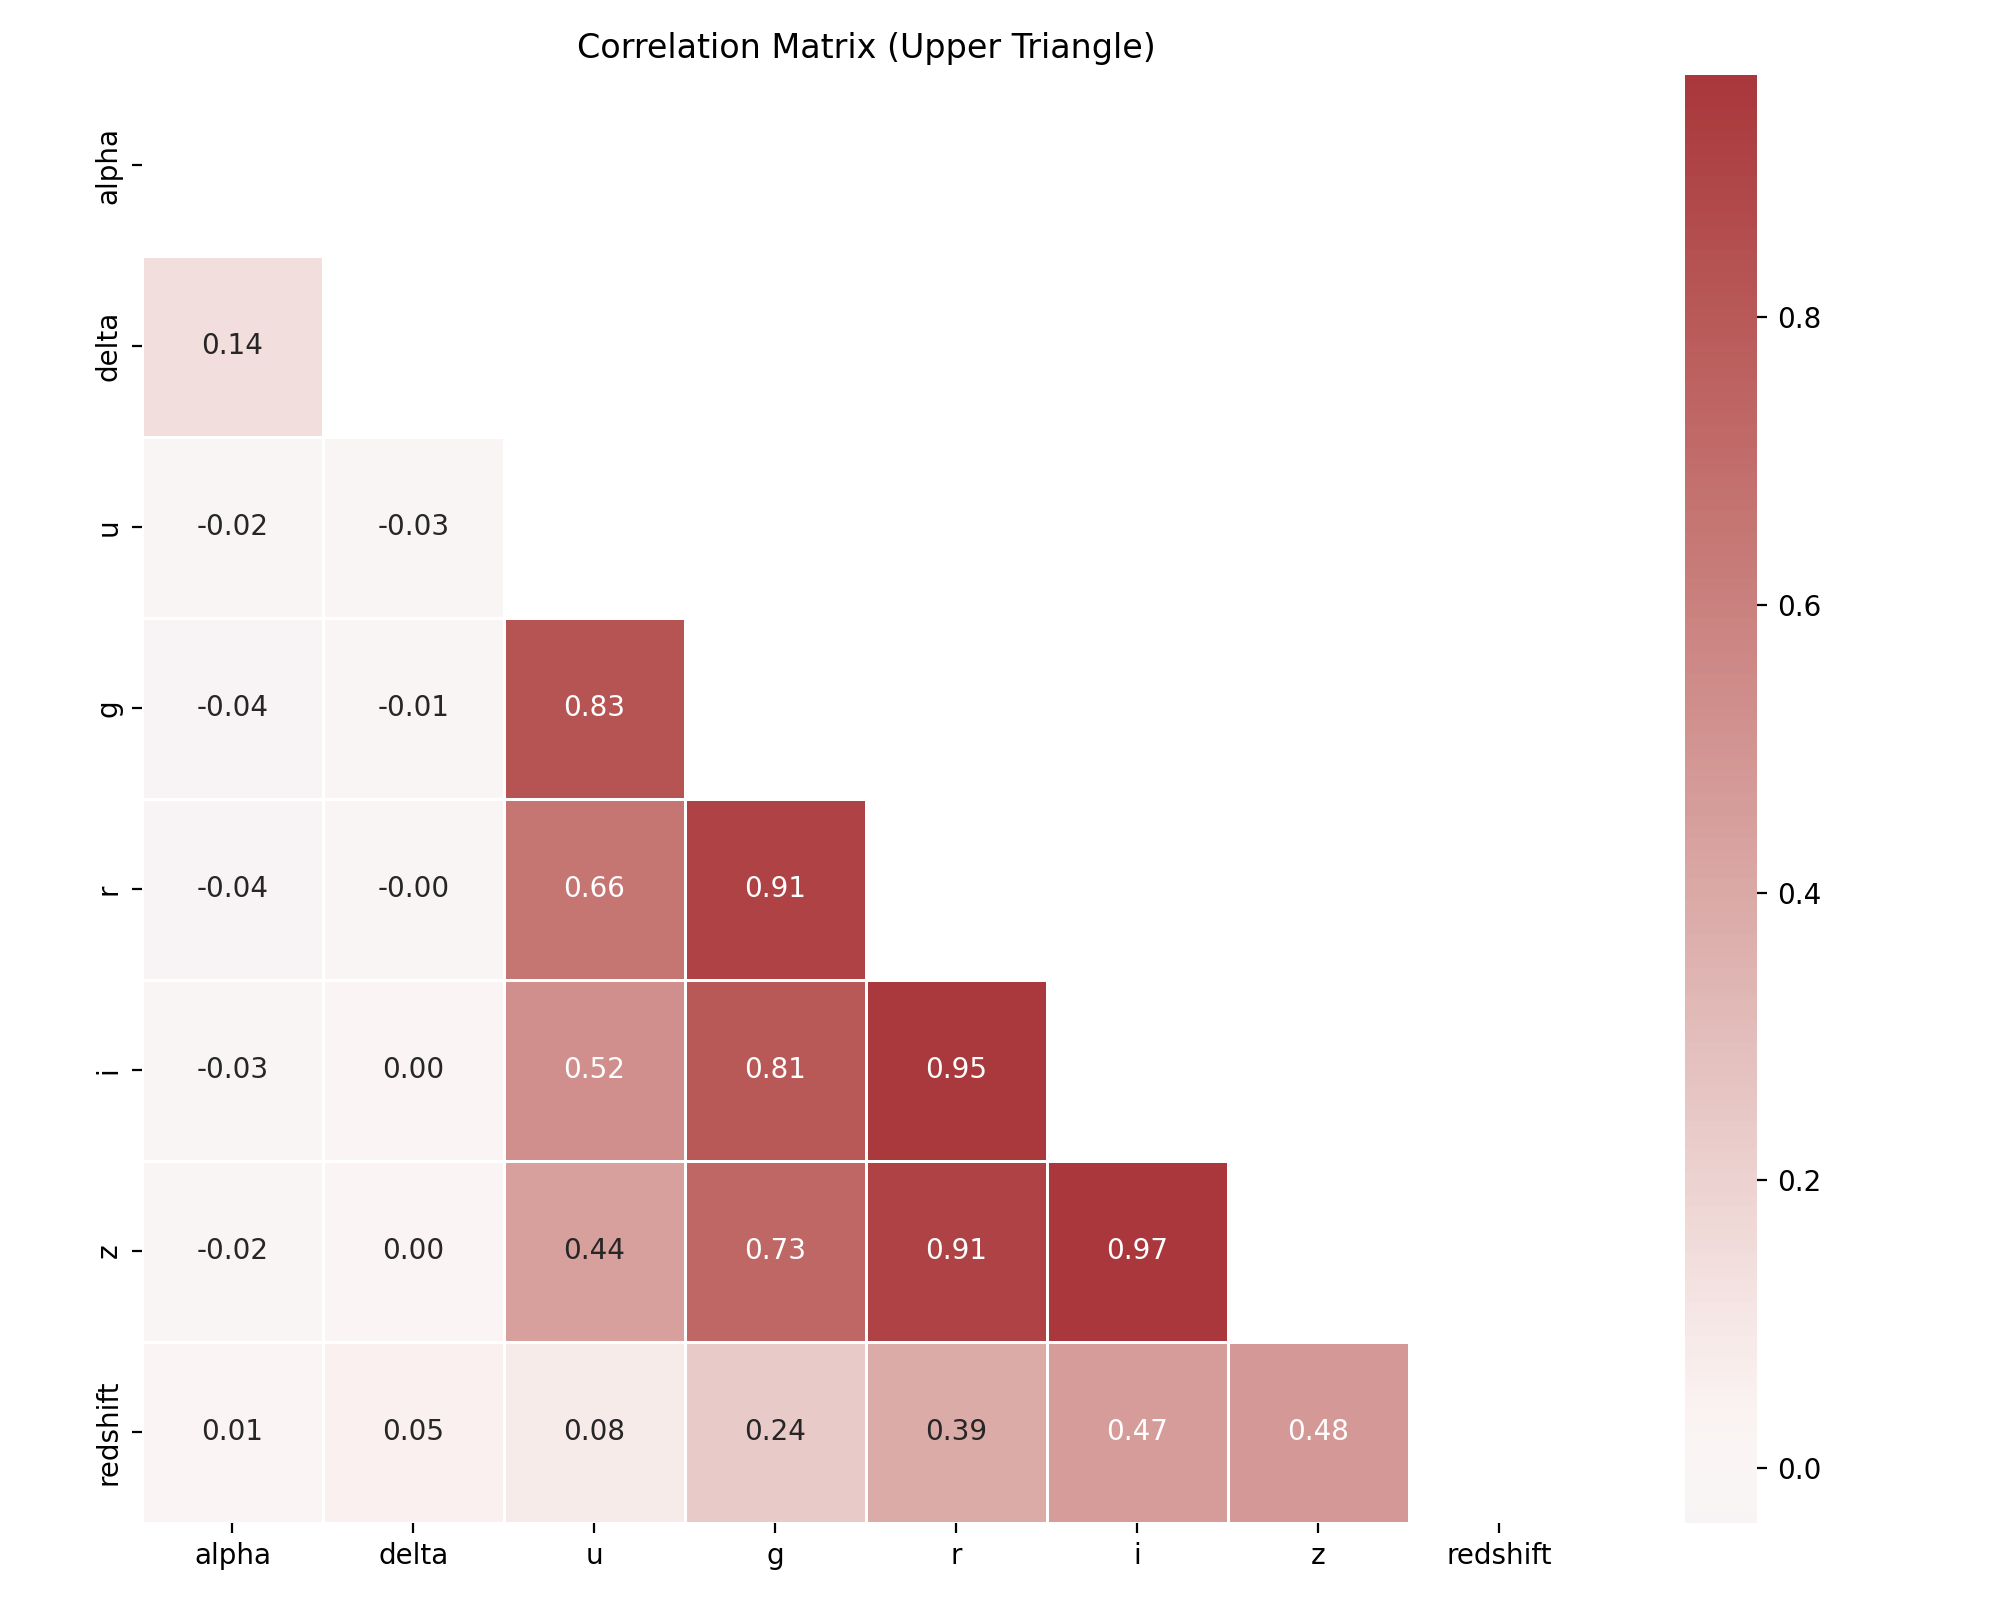

In [853]:
corr_matrix = train_df[NUMERIC_COLS].corr()
display(corr_matrix)

# Показывает только верхнюю треугольную матрицу (без дублирования)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='vlag', 
            center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix (Upper Triangle)')
plt.tight_layout()
plt.show()

### Корреляция с целевой переменной

In [854]:
le = LabelEncoder()
y_encoded = le.fit_transform(train_df['class'])

correlations = []
for col in NUMERIC_COLS:
    corr = train_df[col].corr(pd.Series(y_encoded))
    correlations.append((col, corr))

# Сортируем по абсолютному значению
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("Корреляция признаков с target:")
for col, corr in correlations:
    print(f"{col:15} : {corr:.4f}")

Корреляция признаков с target:
u               : -0.3857
g               : -0.2850
z               : 0.1905
i               : 0.1076
redshift        : 0.0778
r               : -0.0498
alpha           : 0.0336
delta           : 0.0174


# Feature Engineering

В астрофизике разности фотометрических величин (u-g, g-r, r-i, i-z) имеют физический смысл — они показывают цвет объекта. Например:
- i-z характеризует красную часть спектра
- u-g характеризует ультрафиолетовую часть

Эти показатели часто более информативны, чем абсолютные значения, потому что они нормализуют общую яркость объекта.

В астрофизике `color index` вычисляется как:
`color = магнитуда_коротковолнового_фильтра − магнитуда_длинноволнового_фильтра`
То есть вычитают более длинноволновый из более коротковолнового:
- U - B  (ультрафиолет - синий)
- B - V  (синий - визуальный)
- g - r  (зелёный - красный)
- r - i  (красный - ближний ИК)
- i - z  (ближний ИК - ещё более дальний ИК)

Порядок длин волн: u < g < r < i < z

Физический смысл:
- u (ultraviolet) — чувствителен к горячим звёздам, молодым галактикам, квазарам
- g (green) — охватывает синюю и зелёную часть спектра, хорош для звёзд главной последовательности
- r (red) — красный диапазон, важен для старых звёзд и галактик
- i (infrared) — ближний ИК, проникает сквозь пыль, видит холодные объекты
- z (infrared long) — самый длинноволновый фильтр SDSS, используется для обнаружения далёких галактик и коричневых карликов

```
УФ      Видимый свет           Инфракрасный
│       │                      │
u       g──────r──────i        z
│       │      │      │        │
300     400    550    700      850    1000 нм
```

In [855]:
log("Начинаем создание новых признаков...")

# ═══════════════════════════════════════════════════════════════
# 1. БАЗОВЫЕ ТРАНСФОРМАЦИИ
# ═══════════════════════════════════════════════════════════════
train_df['redshift_log'] = np.log1p(train_df['redshift'])
test_df['redshift_log'] = np.log1p(test_df['redshift'])

alpha_rad = np.radians(train_df['alpha'])
delta_rad = np.radians(train_df['delta'])
train_df['sin_alpha'] = np.sin(alpha_rad)
train_df['cos_alpha'] = np.cos(alpha_rad)
train_df['sin_delta'] = np.sin(delta_rad)
train_df['cos_delta'] = np.cos(delta_rad)

alpha_rad_t = np.radians(test_df['alpha'])
delta_rad_t = np.radians(test_df['delta'])
test_df['sin_alpha'] = np.sin(alpha_rad_t)
test_df['cos_alpha'] = np.cos(alpha_rad_t)
test_df['sin_delta'] = np.sin(delta_rad_t)
test_df['cos_delta'] = np.cos(delta_rad_t)

# ═══════════════════════════════════════════════════════════════
# 2. ЦВЕТОВЫЕ ИНДЕКСЫ
# ══════════════════════════════════════════════════════════════
color_pairs = [('u', 'g'), ('g', 'r'), ('r', 'i'), ('i', 'z'), ('r', 'z')]
for c1, c2 in color_pairs:
    name = f'color_{c1}{c2}'
    train_df[name] = train_df[c1] - train_df[c2]
    test_df[name] = test_df[c1] - test_df[c2]

# ═══════════════════════════════════════════════════════════════
# 3. TARGET ENCODING для spectral_type (вероятности классов)
# ═══════════════════════════════════════════════════════════════
# log("Создание Target Encoding для spectral_type...")
# 
# smoothing = 20  # Параметр сглаживания для редких категорий
# global_probs = train_df[TARGET_COL].value_counts(normalize=True)
# 
# Считаем условные вероятности P(class | spectral_type)
# agg = train_df.groupby('spectral_type')[TARGET_COL].value_counts(normalize=True).unstack(fill_value=0)
# counts = train_df.groupby('spectral_type')[TARGET_COL].count()
# 
# for cls in ['STAR', 'GALAXY', 'QSO']:
#     if cls not in agg.columns:
#         agg[cls] = 0.0
#     # Сглаживание Лапласа
#     agg[cls] = (agg[cls] * counts + smoothing * global_probs.get(cls, 0)) / (counts + smoothing)
#     
#     col_name = f'spectral_p_{cls}'
#     train_df[col_name] = train_df['spectral_type'].map(agg[cls])
#     test_df[col_name] = test_df['spectral_type'].map(agg[cls])
#     
#     # Заполняем NaN для неизвестных категорий глобальной вероятностью
#     train_df[col_name] = train_df[col_name].fillna(global_probs.get(cls, 1/3))
#     test_df[col_name] = test_df[col_name].fillna(global_probs.get(cls, 1/3))
# 
# ═══════════════════════════════════════════════════════════════
# 4. ОДНО-ХОТ КОДИРОВАНИЕ для galaxy_population
# ═════════════════════════════════════════════════════════════
# log("Создание One-Hot Encoding для galaxy_population...")

# for pop in ['Red_Sequence', 'Blue_Cloud']:
#     col_name = f'pop_is_{pop}'
#     train_df[col_name] = (train_df['galaxy_population'] == pop).astype(int)
#     test_df[col_name] = (test_df['galaxy_population'] == pop).astype(int)

# ═══════════════════════════════════════════════════════════════
# 5. УСЛОВНЫЕ СРЕДНИЕ ЦВЕТА И ОТКЛОНЕНИЯ (z-score)
# ═══════════════════════════════════════════════════════════════
log("Создание признаков отклонения от условных средних цветов...")

# Считаем средние и стандартные отклонения цветов для каждого спектрального типа
color_cols = ['color_ug', 'color_gr', 'color_ri', 'color_rz']
for color_col in color_cols:
    stats = train_df.groupby('spectral_type')[color_col].agg(['mean', 'std'])
    stats['std'] = stats['std'].fillna(1.0)  # Защита от деления на 0
    
    # Отклонение от среднего (z-score)
    z_col = f'z_{color_col}_by_spectral'
    train_df[z_col] = (
        train_df[color_col] - train_df['spectral_type'].map(stats['mean'])
    ) / train_df['spectral_type'].map(stats['std'])
    test_df[z_col] = (
        test_df[color_col] - test_df['spectral_type'].map(stats['mean'])
    ) / test_df['spectral_type'].map(stats['std'])
    
    train_df[z_col] = train_df[z_col].fillna(0)
    test_df[z_col] = test_df[z_col].fillna(0)

# Условные средние для galaxy_population
for color_col in ['color_gr', 'color_ri']:
    stats_pop = train_df.groupby('galaxy_population')[color_col].agg(['mean', 'std'])
    stats_pop['std'] = stats_pop['std'].fillna(1.0)
    
    z_col = f'z_{color_col}_by_pop'
    train_df[z_col] = (
        train_df[color_col] - train_df['galaxy_population'].map(stats_pop['mean'])
    ) / train_df['galaxy_population'].map(stats_pop['std'])
    test_df[z_col] = (
        test_df[color_col] - test_df['galaxy_population'].map(stats_pop['mean'])
    ) / test_df['galaxy_population'].map(stats_pop['std'])
    
    train_df[z_col] = train_df[z_col].fillna(0)
    test_df[z_col] = test_df[z_col].fillna(0)

# ═══════════════════════════════════════════════════════════════
# 6. ВЗАИМОДЕЙСТВИЯ С REDSHIFT
# ═══════════════════════════════════════════════════════════════
log("Создание взаимодействий с redshift...")

# Произведения redshift на цвета (эволюционные тренды)
for color_col in ['color_gr', 'color_ug', 'color_rz', 'color_ri']:
    name = f'z_x_{color_col}'
    train_df[name] = train_df['redshift'] * train_df[color_col]
    test_df[name] = test_df['redshift'] * test_df[color_col]

# Космологическая коррекция цвета: (g-r) / (1+z)
train_df['color_gr_corrected'] = train_df['color_gr'] / (1 + train_df['redshift'])
test_df['color_gr_corrected'] = test_df['color_gr'] / (1 + test_df['redshift'])

# Логарифмическое взаимодействие
train_df['redshift_log_x_color_gr'] = train_df['redshift_log'] * train_df['color_gr']
test_df['redshift_log_x_color_gr'] = test_df['redshift_log'] * test_df['color_gr']

# Lookback time proxy
train_df['lookback_proxy'] = train_df['redshift'] / (1 + train_df['redshift'])
test_df['lookback_proxy'] = test_df['redshift'] / (1 + test_df['redshift'])

# ═══════════════════════════════════════════════════════════════
# 7. ПРИЗНАКИ ДЛЯ КВАЗАРОВ ВЫСОКОГО Z (эффект Лайман-альфа)
# ═══════════════════════════════════════════════════════════════
log("Создание признаков для квазаров высокого z...")

# Индекс красноты: (u-g) / (g-r)
train_df['reddeness_index'] = train_df['color_ug'] / (train_df['color_gr'] + 1e-5)
test_df['reddeness_index'] = test_df['color_ug'] / (test_df['color_gr'] + 1e-5)

# Флаг высокозначимого квазара (z > 2.2)
train_df['high_z_quasar_flag'] = (
    (train_df['redshift'] > 2.2) & 
    (train_df['color_ug'] > 1.0) & 
    (train_df['color_gr'] > 0.5)
).astype(int)
test_df['high_z_quasar_flag'] = (
    (test_df['redshift'] > 2.2) & 
    (test_df['color_ug'] > 1.0) & 
    (test_df['color_gr'] > 0.5)
).astype(int)

# Индикатор "крыла Лайман-альфа"
train_df['lya_wing_indicator'] = np.where(
    train_df['redshift'] > 2.2,
    (train_df['redshift'] - 2.2) * train_df['color_ug'],
    0
)
test_df['lya_wing_indicator'] = np.where(
    test_df['redshift'] > 2.2,
    (test_df['redshift'] - 2.2) * test_df['color_ug'],
    0
)

# ═══════════════════════════════════════════════════════════════
# 8. ГАЛАКТИЧЕСКИЕ КООРДИНАТЫ
# ═══════════════════════════════════════════════════════════════
log("Вычисление галактических координат...")

def equatorial_to_galactic(alpha_deg, delta_deg):
    """
    Перевод экваториальных координат (α, δ) в галактические (l, b).
    Параметры северного галактического полюса (J2000):
    α_NGP = 192.85948°, δ_NGP = 27.12825°, l_NCP = 122.93192°
    """
    alpha_NGP = np.radians(192.85948)
    delta_NGP = np.radians(27.12825)
    l_NCP = np.radians(122.93192)
    
    alpha = np.radians(alpha_deg)
    delta = np.radians(delta_deg)
    
    # Галактическая широта b
    sin_b = (np.sin(delta) * np.sin(delta_NGP) + 
             np.cos(delta) * np.cos(delta_NGP) * np.cos(alpha - alpha_NGP))
    b = np.arcsin(np.clip(sin_b, -1, 1))
    
    # Галактическая долгота l
    y = np.cos(delta) * np.sin(alpha - alpha_NGP)
    x = (np.sin(delta) * np.cos(delta_NGP) - 
         np.cos(delta) * np.sin(delta_NGP) * np.cos(alpha - alpha_NGP))
    l = l_NCP - np.arctan2(y, x)
    l = np.mod(l, 2 * np.pi)
    
    return np.degrees(l), np.degrees(b)

# Вычисляем для train
train_l, train_b = equatorial_to_galactic(train_df['alpha'], train_df['delta'])
train_df['galactic_lat_b'] = train_b
train_df['galactic_lon_l'] = train_l

# Вычисляем для test
test_l, test_b = equatorial_to_galactic(test_df['alpha'], test_df['delta'])
test_df['galactic_lat_b'] = test_b
test_df['galactic_lon_l'] = test_l

# Производные признаки от галактической широты
train_df['abs_galactic_latitude'] = np.abs(train_df['galactic_lat_b'])
test_df['abs_galactic_latitude'] = np.abs(test_df['galactic_lat_b'])

train_df['contamination_risk'] = 1.0 / (1.0 + train_df['abs_galactic_latitude'])
test_df['contamination_risk'] = 1.0 / (1.0 + test_df['abs_galactic_latitude'])

# Тригонометрия галактических координат
train_df['sin_gal_b'] = np.sin(np.radians(train_df['galactic_lat_b']))
train_df['cos_gal_b'] = np.cos(np.radians(train_df['galactic_lat_b']))
test_df['sin_gal_b'] = np.sin(np.radians(test_df['galactic_lat_b']))
test_df['cos_gal_b'] = np.cos(np.radians(test_df['galactic_lat_b']))

# ═══════════════════════════════════════════════════════════════
# 9. ЦВЕТ-МАГНИТУДНЫЕ ЗАВИСИМОСТИ
# ═══════════════════════════════════════════════════════════════
log("Создание цвет-магнитудных признаков...")

# Произведения цветов на звездные величины
for color_col in ['color_gr', 'color_ug', 'color_rz']:
    for mag_col in ['r', 'g', 'i']:
        name = f'{color_col}_x_{mag_col}'
        train_df[name] = train_df[color_col] * train_df[mag_col]
        test_df[name] = test_df[color_col] * test_df[mag_col]

# ═══════════════════════════════════════════════════════════════
# 10. ИНДЕКСЫ ЯРКОСТИ И ДИСПЕРСИИ
# ═══════════════════════════════════════════════════════════════
log("Создание признаков яркости...")

mag_cols = ['u', 'g', 'r', 'i', 'z']
train_df['total_brightness'] = train_df[mag_cols].sum(axis=1)
train_df['brightness_mean'] = train_df[mag_cols].mean(axis=1)
train_df['brightness_std'] = train_df[mag_cols].std(axis=1)
train_df['brightness_range'] = train_df[mag_cols].max(axis=1) - train_df[mag_cols].min(axis=1)

test_df['total_brightness'] = test_df[mag_cols].sum(axis=1)
test_df['brightness_mean'] = test_df[mag_cols].mean(axis=1)
test_df['brightness_std'] = test_df[mag_cols].std(axis=1)
test_df['brightness_range'] = test_df[mag_cols].max(axis=1) - test_df[mag_cols].min(axis=1)

# ═══════════════════════════════════════════════════════════════
# 11. ПРИЗНАКИ ДЛЯ ПЕРЕХОДНЫХ ЗОН REDSHIFT
# ══════════════════════════════════════════════════════════════
log("Создание признаков переходных зон...")

# Гауссов индикатор переходной зоны около z=0.1 (звезды/галактики)
train_df['transition_z_01'] = np.exp(-0.5 * ((train_df['redshift'] - 0.1) / 0.05) ** 2)
test_df['transition_z_01'] = np.exp(-0.5 * ((test_df['redshift'] - 0.1) / 0.05) ** 2)

# Индикатор "близкий объект" (звезда)
# train_df['is_nearby'] = (train_df['redshift'] < 0.01).astype(int)
# test_df['is_nearby'] = (test_df['redshift'] < 0.01).astype(int)

# Биннинг redshift
bins_z = [0, 0.1, 0.3, 0.5, 1.0, 2.2, 10]
train_df['redshift_bin'] = pd.cut(train_df['redshift'], bins=bins_z, labels=False).fillna(0).astype(int)
test_df['redshift_bin'] = pd.cut(test_df['redshift'], bins=bins_z, labels=False).fillna(0).astype(int)

# ═══════════════════════════════════════════════════════════════
# 12. РАССТОЯНИЕ ДО НАЧАЛА КООРДИНАТ И ВЗАИМОДЕЙСТВИЯ
# ═══════════════════════════════════════════════════════════════
train_df['coord_dist'] = np.sqrt(train_df['alpha']**2 + train_df['delta']**2)
test_df['coord_dist'] = np.sqrt(test_df['alpha']**2 + test_df['delta']**2)

train_df['coord_x_redshift'] = train_df['coord_dist'] * train_df['redshift_log']
test_df['coord_x_redshift'] = test_df['coord_dist'] * test_df['redshift_log']

# Взаимодействие галактической широты с redshift
train_df['gal_b_x_redshift'] = train_df['galactic_lat_b'] * train_df['redshift_log']
test_df['gal_b_x_redshift'] = test_df['galactic_lat_b'] * test_df['redshift_log']

# ═══════════════════════════════════════════════════════════════
# Удаляем оригинальные категориальные колонки
# ═══════════════════════════════════════════════════════════════
train_df = train_df.drop(columns=['spectral_type', 'galaxy_population'])
test_df = test_df.drop(columns=['spectral_type', 'galaxy_population'])

log(f"Создание признаков завершено")
log(f"Всего колонок в train: {len(train_df.columns)}")
log(f"Всего колонок в test: {len(test_df.columns)}")

[17:35:33] Начинаем создание новых признаков...
[17:35:33] Создание признаков отклонения от условных средних цветов...
[17:35:34] Создание взаимодействий с redshift...
[17:35:34] Создание признаков для квазаров высокого z...
[17:35:34] Вычисление галактических координат...
[17:35:34] Создание цвет-магнитудных признаков...
[17:35:34] Создание признаков яркости...
[17:35:34] Создание признаков переходных зон...
[17:35:34] Создание признаков завершено
[17:35:34] Всего колонок в train: 60
[17:35:34] Всего колонок в test: 59


# Baseline. LightGBM

In [856]:
# Подготовка данных
X_train = train_df.drop(columns=[ID_COL, TARGET_COL])
y_train = train_df[TARGET_COL]
X_test = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL]

In [857]:
# 5-FOLD КРОСС-ВАЛИДАЦИЯ
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_scores = []
oof_predictions = np.zeros((len(X_train), 3))  # Для 3 классов

log(f"Начинаем {n_splits}-fold кросс-валидацию...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    log(f"Fold {fold}/{n_splits}...")
    
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model_fold = LGBMClassifier(
        n_estimators=500,        # Было 2000 → в 4 раза быстрее
        learning_rate=0.1,       # Было 0.03 → компенсируем меньшее число деревьев
        max_depth=8,             # Было 10 → чуть проще
        num_leaves=31,           # Было 63 → меньше вариантов разбиений
        min_child_samples=20,    # Было 10 → меньше переобучения на малых выборках
        subsample=0.8,           # Было 0.9
        colsample_bytree=0.8,    # Было 0.9
        class_weight='balanced',
        random_state=42,
        verbose=-1               # Полная тишина
    )
    
    model_fold.fit(X_fold_train, y_fold_train)
    
    # Out-of-fold предсказания (вероятности)
    oof_predictions[val_idx] = model_fold.predict_proba(X_fold_val)
    
    # Оценка на валидации этого фолда
    fold_pred = model_fold.predict(X_fold_val)
    fold_score = balanced_accuracy_score(y_fold_val, fold_pred)
    fold_scores.append(fold_score)
    
    log(f"  Fold {fold} BalAcc: {fold_score:.4f}")

# Усреднённая метрика по всем фолдам
mean_cv_score = np.mean(fold_scores)
std_cv_score = np.std(fold_scores)

log(f"\nK-Fold CV результат:")
log(f"  Mean BalAcc: {mean_cv_score:.4f} ± {std_cv_score:.4f}")
log(f"  Min: {min(fold_scores):.4f}, Max: {max(fold_scores):.4f}")

# OOF предсказания (классы)
oof_classes = model_fold.classes_[np.argmax(oof_predictions, axis=1)]
oof_score = balanced_accuracy_score(y_train, oof_classes)
log(f"  OOF BalAcc: {oof_score:.4f}")

# ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ НА ВСЕХ ДАННЫХ
model_lgb_final = LGBMClassifier(
    n_estimators=500,        # Было 2000 → в 4 раза быстрее
    learning_rate=0.1,       # Было 0.03 → компенсируем меньшее число деревьев
    max_depth=8,             # Было 10 → чуть проще
    num_leaves=31,           # Было 63 → меньше вариантов разбиений
    min_child_samples=20,    # Было 10 → меньше переобучения на малых выборках
    subsample=0.8,           # Было 0.9
    colsample_bytree=0.8,    # Было 0.9
    class_weight='balanced',
    random_state=42,
    verbose=-1               # Полная тишина
)

model_lgb_final.fit(X_train, y_train)
log("\nФинальная модель обучена на всех данных train")

predictions = model_lgb_final.predict(X_test)

log(f"Количество предсказаний: {len(predictions)}")
log(f"Распределение классов:")
log(pd.Series(predictions).value_counts())

# ОЦЕНКА НА ВАЛИДАЦИИ (для логирования)
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train
)

y_pred_lgb = model_lgb_final.predict(X_val)

train_score = balanced_accuracy_score(y_train_fit, model_lgb_final.predict(X_train_fit))
val_score = balanced_accuracy_score(y_val, y_pred_lgb)

log_experiment(
    model_name='LightGBM',
    params=model_lgb_final.get_params(),
    train_score=train_score,
    val_score=val_score,
    features_info='base + color_indices + coord + redshift_log + galactic_coords + target_encoding_spectral + z_score_colors + z_interactions + quasar_features + brightness_stats'
)

[17:35:34] Начинаем 3-fold кросс-валидацию...
[17:35:34] Fold 1/3...
[17:35:53]   Fold 1 BalAcc: 0.9642
[17:35:53] Fold 2/3...
[17:36:10]   Fold 2 BalAcc: 0.9645
[17:36:10] Fold 3/3...
[17:36:28]   Fold 3 BalAcc: 0.9626
[17:36:28] 
K-Fold CV результат:
[17:36:28]   Mean BalAcc: 0.9638 ± 0.0008
[17:36:28]   Min: 0.9626, Max: 0.9645
[17:36:29]   OOF BalAcc: 0.9638
[17:36:50] 
Финальная модель обучена на всех данных train
[17:36:52] Количество предсказаний: 247435
[17:36:52] Распределение классов:
[17:36:53] GALAXY    156532
QSO        51345
STAR       39558
Name: count, dtype: int64
Результат сохранён в experiments_log.csv
          timestamp               model  train_bal_acc  val_bal_acc       gap                                                                                                                                                                                                                                                                                                      

,timestamp,model,train_bal_acc,val_bal_acc,gap,params,features
0,2026-06-04 15:18:25,CatBoost,0.962996,0.960587,0.002409,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices
1,2026-06-04 15:23:19,CatBoost,0.962996,0.960587,0.002409,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + alph...
2,2026-06-04 15:30:33,CatBoost,0.963335,0.960685,0.002650,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist
3,2026-06-04 15:40:41,CatBoost,0.963105,0.960572,0.002532,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...
4,2026-06-04 15:44:04,CatBoost,0.963105,0.960572,0.002532,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...
5,2026-06-04 15:46:59,CatBoost,0.963122,0.960369,0.002753,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...
6,2026-06-04 15:54:58,CatBoost,0.962871,0.960507,0.002364,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...
7,2026-06-04 16:16:39,CatBoost,0.963043,0.960491,0.002552,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...
8,2026-06-04 16:24:36,CatBoost,0.966600,0.961449,0.005151,"{'iterations': 1000, 'learning_rate': 0.05, 'd...",base + color_indices (-iz) + coord_dist + reds...
9,2026-06-04 17:04:45,CatBoost,0.966446,0.961335,0.005111,"{'iterations': 1000, 'learning_rate': 0.05, 'd...",base + color_indices (-iz) + coord_dist + reds...


Топ-75 важных признаков:
                Feature  Importance
               redshift        2135
         galactic_lon_l        1777
                  delta        1743
              cos_delta        1627
              sin_alpha        1585
         brightness_std        1370
              cos_alpha        1367
                      z        1245
        transition_z_01        1233
                      u        1229
                      g        1214
                      r        1120
       gal_b_x_redshift        1096
                      i        1075
           z_x_color_ri        1055
       brightness_range        1018
       coord_x_redshift         999
               color_iz         949
         galactic_lat_b         920
           z_x_color_rz         900
                  alpha         899
       total_brightness         876
 z_color_gr_by_spectral         857
             coord_dist         831
     contamination_risk         826
  abs_galactic_latitude         788
 z_

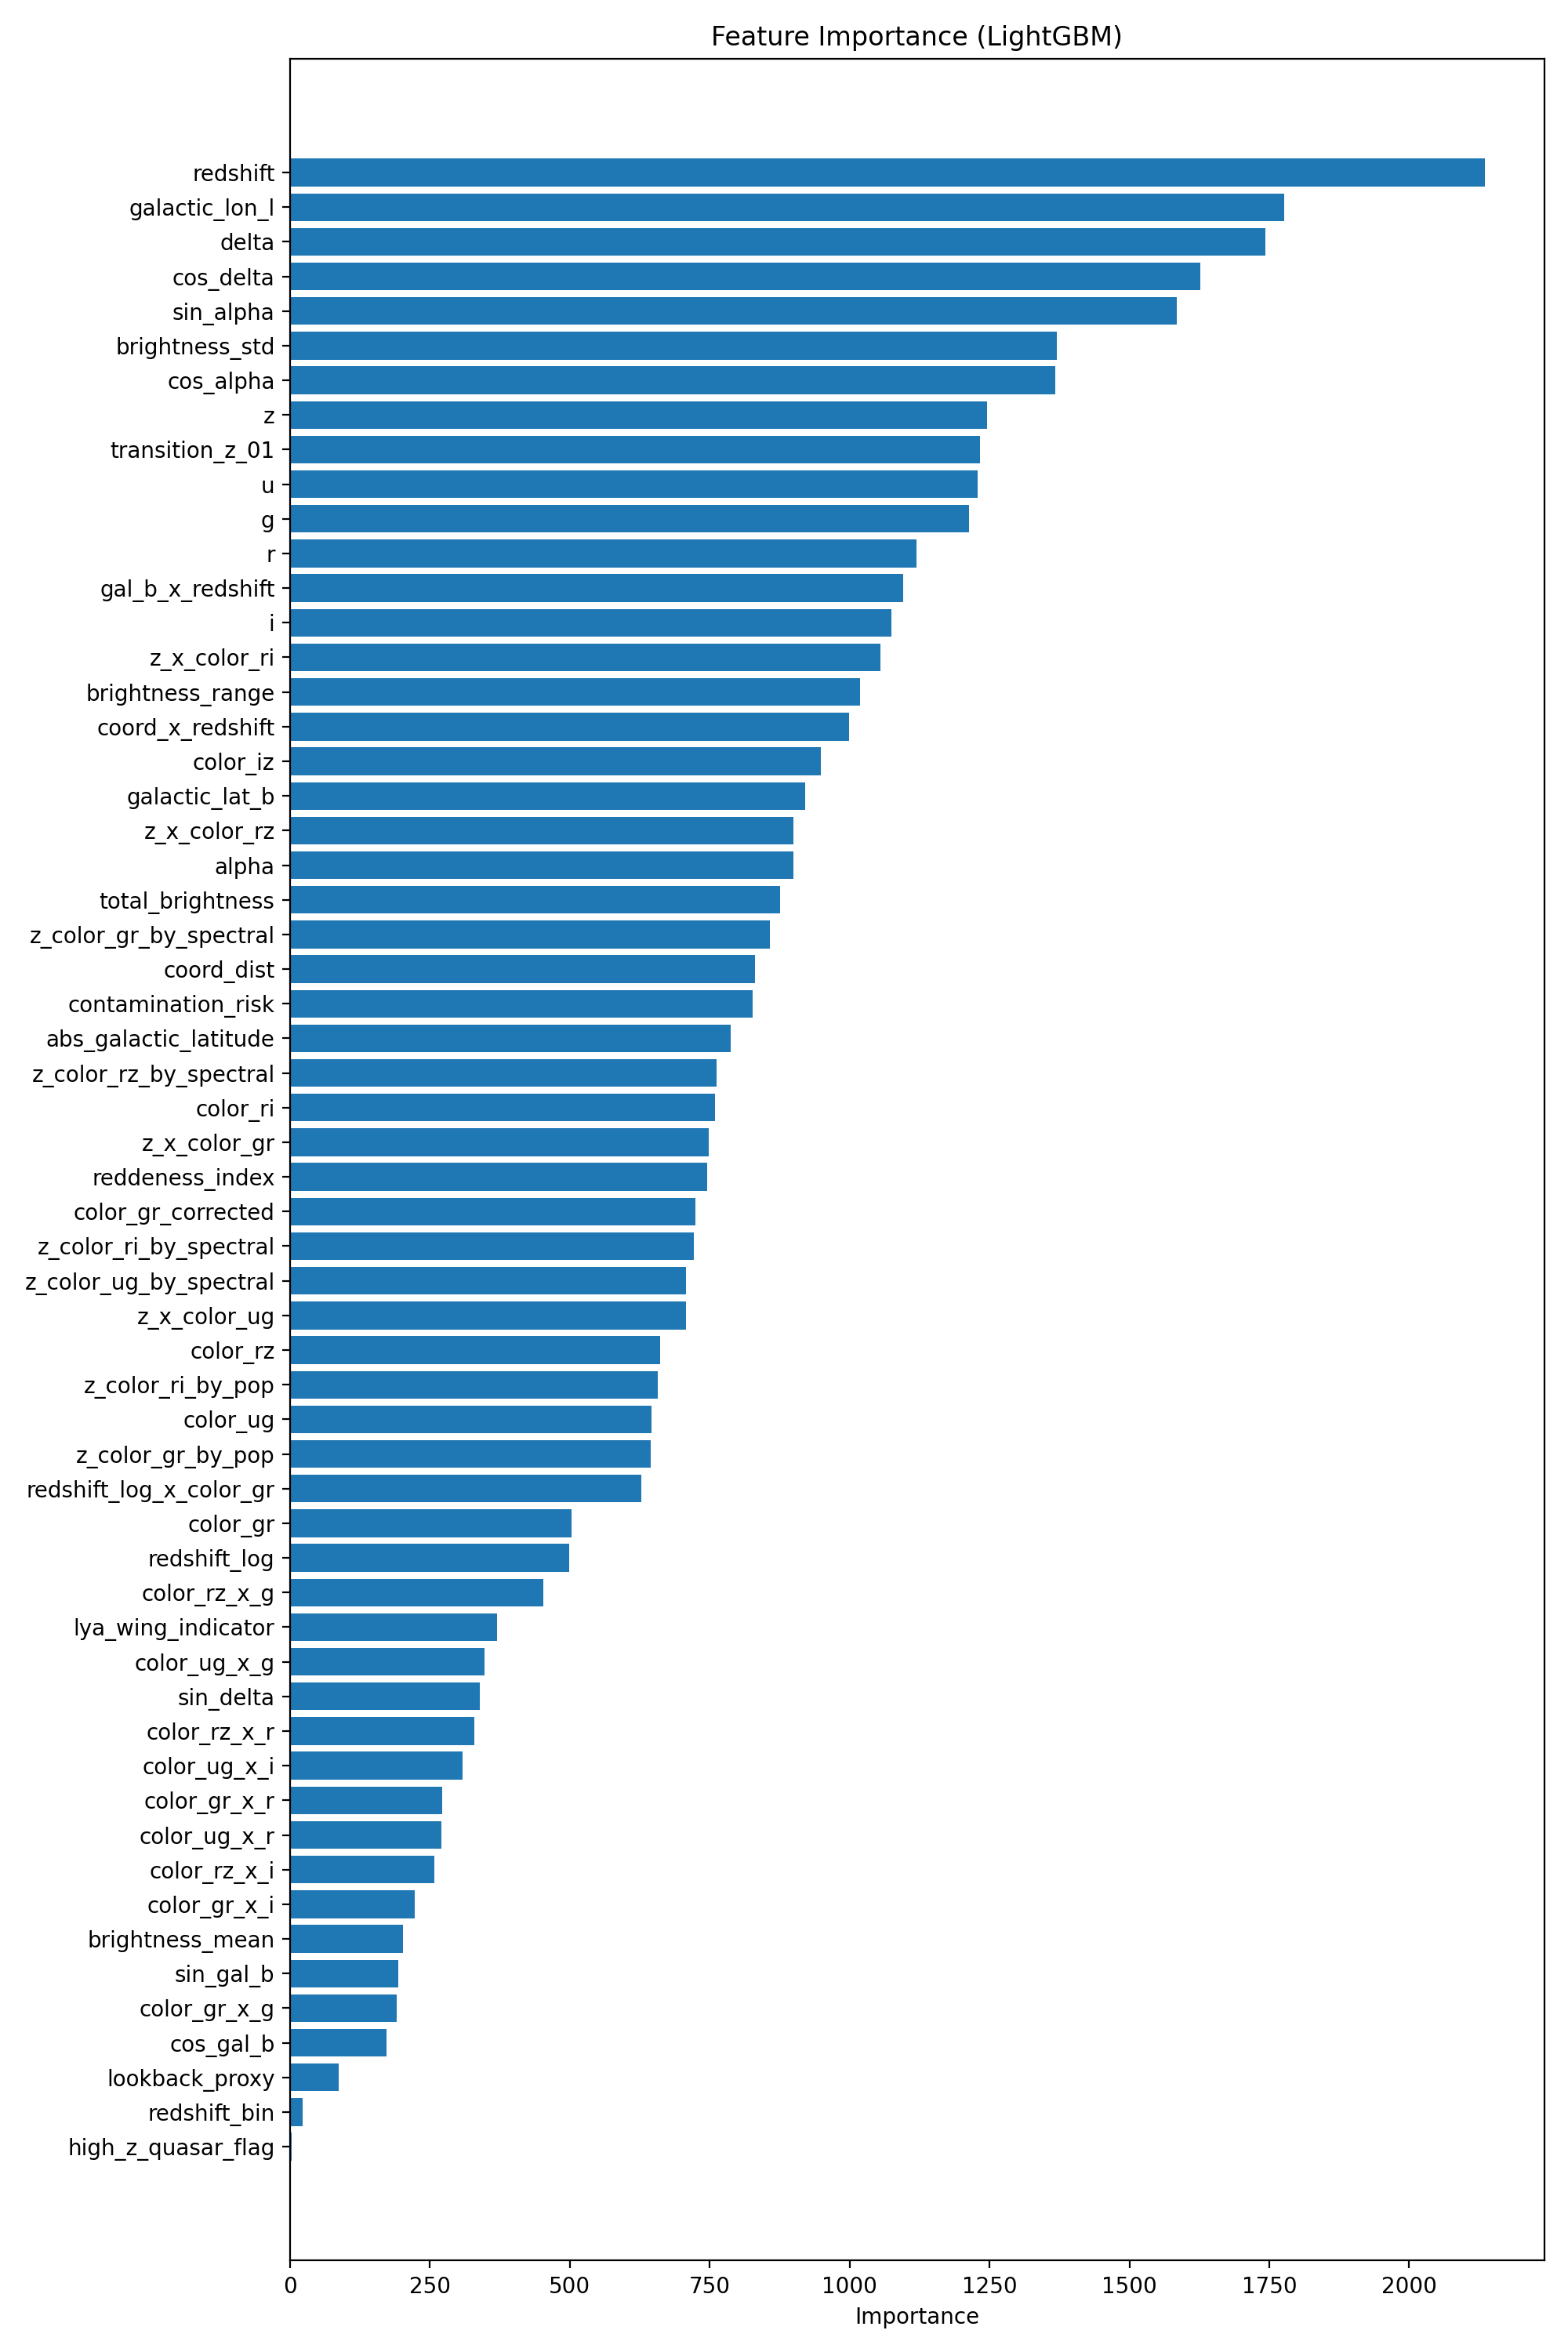

In [858]:
# Получаем важность признаков
importances = model_lgb_final.feature_importances_

# Получаем названия признаков
feature_names = X_train.columns.tolist()

# Создаём DataFrame для удобства
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Топ-75 важных признаков:")
print(fi_df.head(75).to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 15))
plt.barh(fi_df['Feature'][:75][::-1], fi_df['Importance'][:75][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()

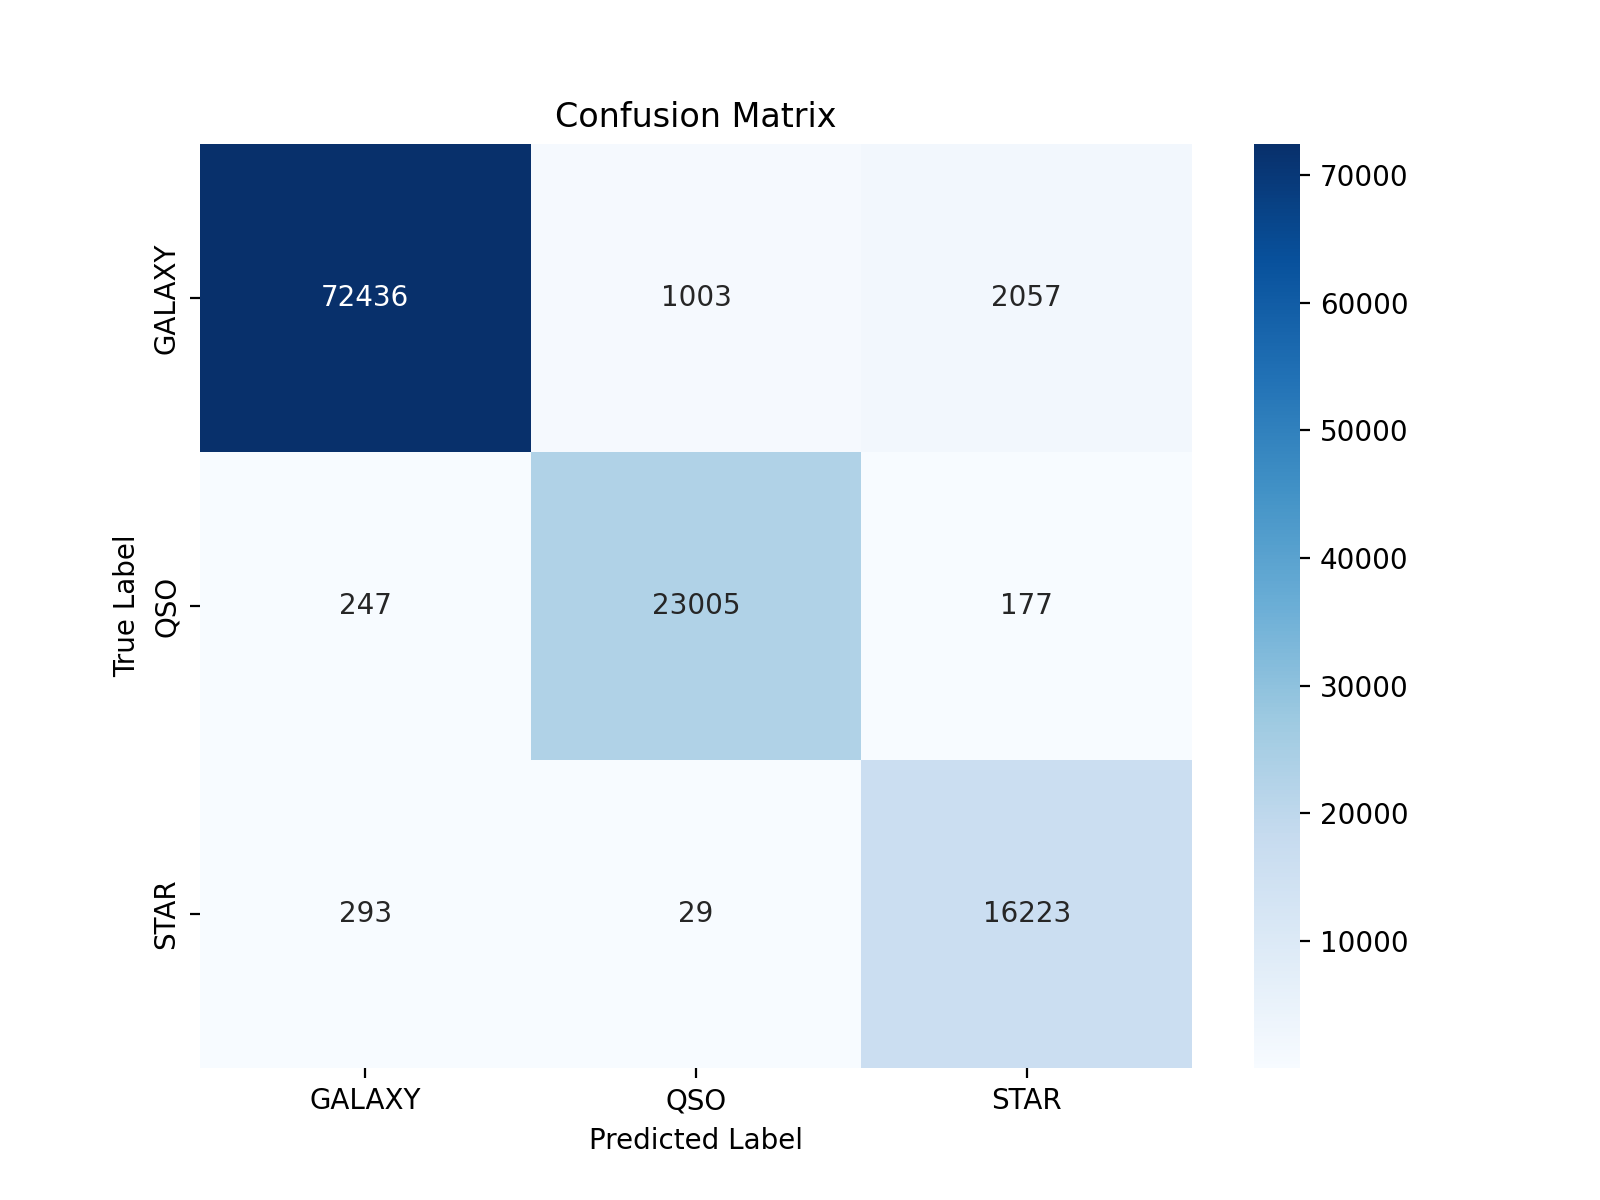

              precision    recall  f1-score   support

      GALAXY       0.99      0.96      0.98     75496
         QSO       0.96      0.98      0.97     23429
        STAR       0.88      0.98      0.93     16545

    accuracy                           0.97    115470
   macro avg       0.94      0.97      0.96    115470
weighted avg       0.97      0.97      0.97    115470



In [859]:
cm = confusion_matrix(y_val, y_pred_lgb, labels=['GALAXY', 'QSO', 'STAR'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Отчёт по классам
print(classification_report(y_val, y_pred_lgb))

In [860]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: predictions.flatten()
})

submission.to_csv('submission.csv', index=False)
print(f"Balanced Accuracy на train: {model_lgb_final.score(X_train, y_train):.4f}")

Balanced Accuracy на train: 0.9668


Загружено экспериментов: 31
Лучший val_bal_acc: 0.9912 (Эксперимент #27)


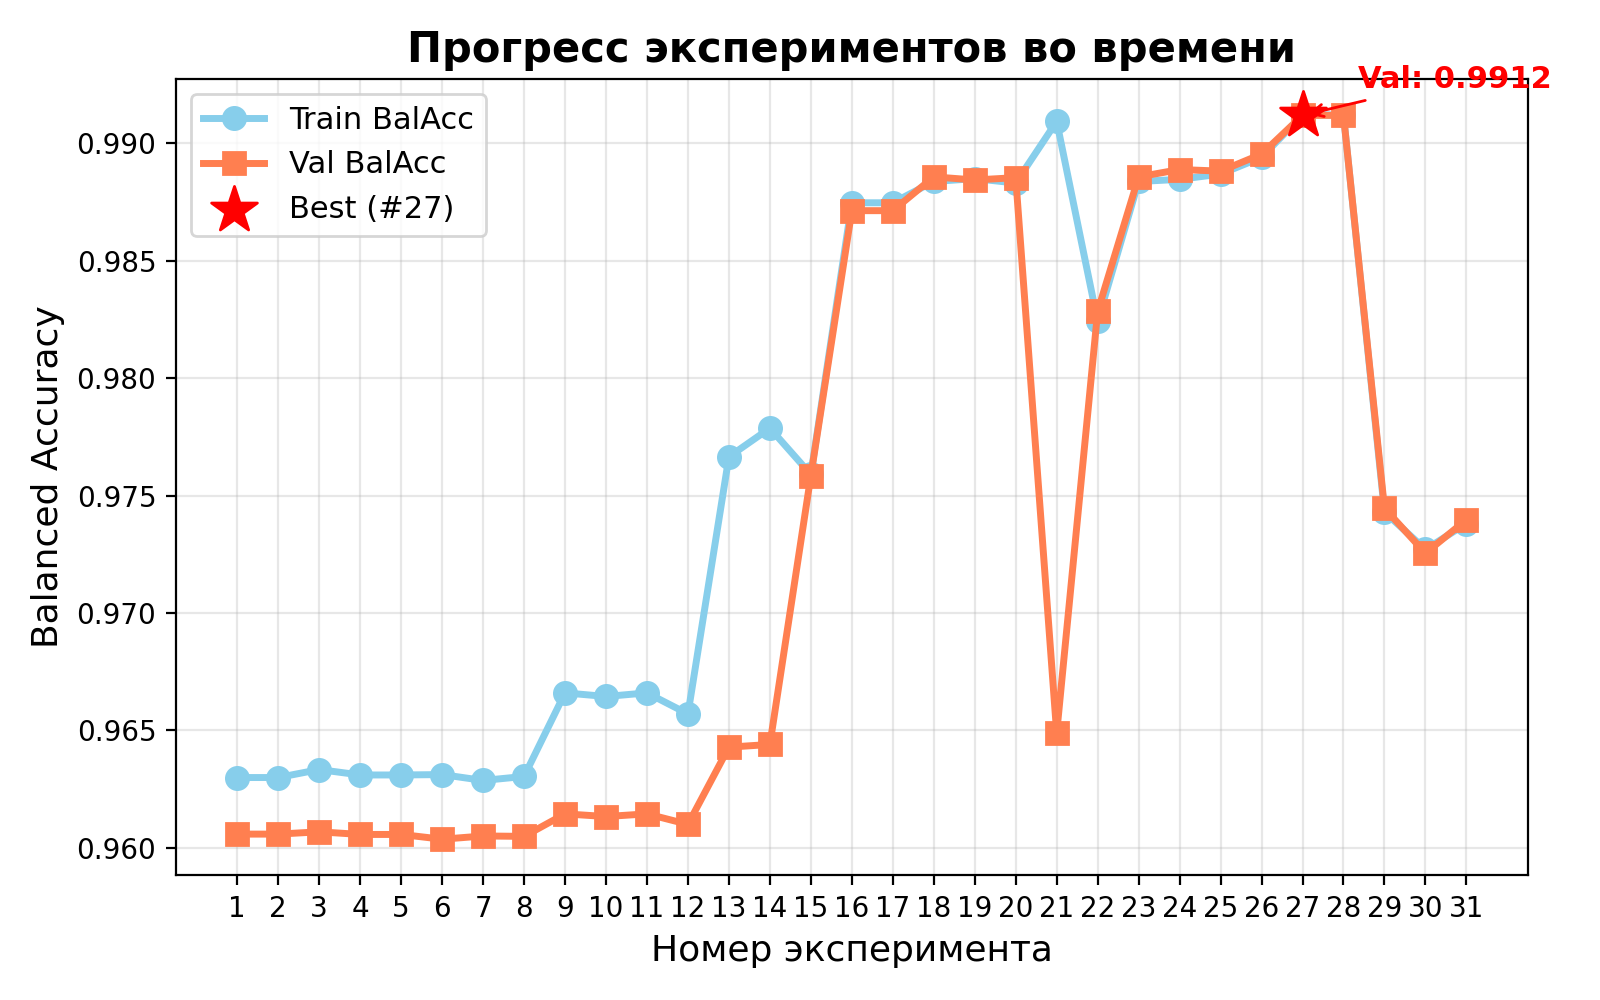

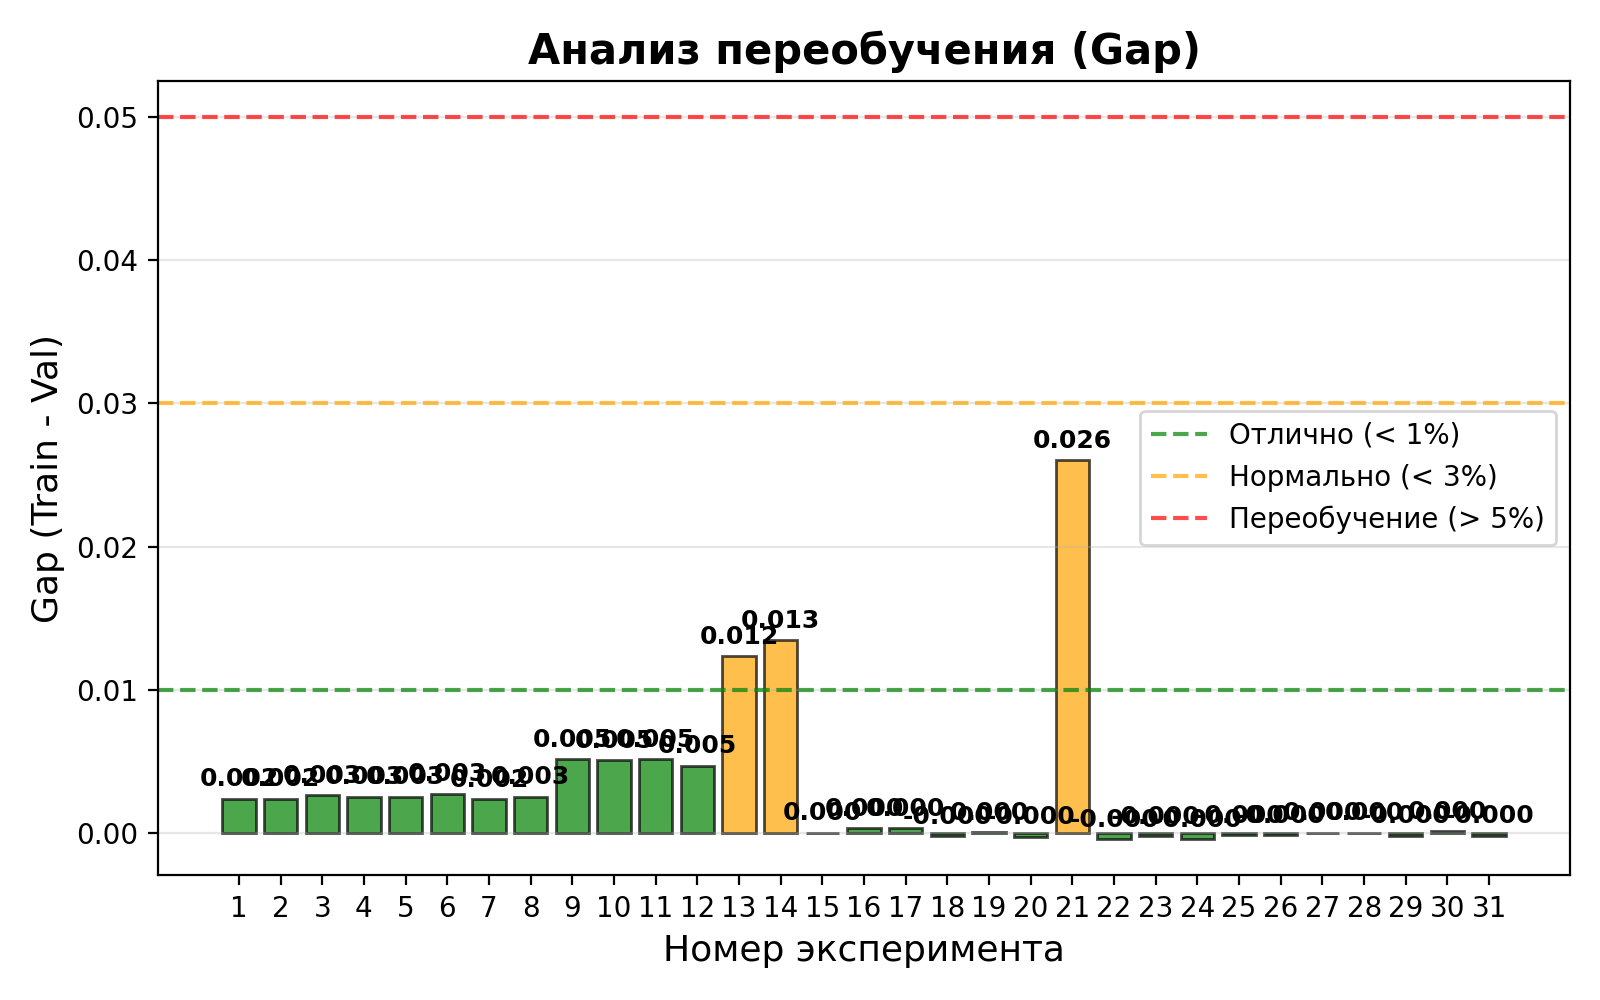


Сводная таблица экспериментов:


,Best,#,Model,Depth,LR,Iters,Train,Val,Gap,Features
0,,1,CatBoost,6.000000,0.100000,500.000000,0.9630,0.9606,0.0024,base + color_indices
1,,2,CatBoost,6.000000,0.100000,500.000000,0.9630,0.9606,0.0024,base + color_indices (-iz) + coord_dist + alpha_bin + delta_bin
2,,3,CatBoost,6.000000,0.100000,500.000000,0.9633,0.9607,0.0026,base + color_indices (-iz) + coord_dist
3,,4,CatBoost,6.000000,0.100000,500.000000,0.9631,0.9606,0.0025,base + color_indices (-iz) + coord_dist + redshift_log
4,,5,CatBoost,6.000000,0.100000,500.000000,0.9631,0.9606,0.0025,base + color_indices (-iz) + coord_dist + redshift_log (-redshift)
5,,6,CatBoost,6.000000,0.100000,500.000000,0.9631,0.9604,0.0028,base + color_indices (-iz) + coord_dist + redshift_log (-redshift)
6,,7,CatBoost,6.000000,0.100000,500.000000,0.9629,0.9605,0.0024,"base + color_indices (-iz) + coord_dist + redshift_log (-redshift) + (l2_leaf_reg=5, random_strength=2)"
7,,8,CatBoost,6.000000,0.100000,500.000000,0.9630,0.9605,0.0026,base + color_indices (-iz) + coord_dist + redshift_log (-redshift)
8,,9,CatBoost,8.000000,0.050000,1000.000000,0.9666,0.9614,0.0052,base + color_indices (-iz) + coord_dist + redshift_log (-redshift)
9,,10,CatBoost,8.000000,0.050000,1000.000000,0.9664,0.9613,0.0051,base + color_indices (-iz) + coord_dist + redshift_log (-redshift) + индикаторы для spectral_type и galaxy_population


,timestamp,model,train_bal_acc,val_bal_acc,gap,params,features,exp_num,params_dict,depth,learning_rate,iterations,l2_leaf_reg
0,2026-06-04 15:18:25,CatBoost,0.962996,0.960587,0.002409,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices,1,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,NaN
1,2026-06-04 15:23:19,CatBoost,0.962996,0.960587,0.002409,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + alph...,2,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,NaN
2,2026-06-04 15:30:33,CatBoost,0.963335,0.960685,0.002650,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist,3,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,NaN
3,2026-06-04 15:40:41,CatBoost,0.963105,0.960572,0.002532,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...,4,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,NaN
4,2026-06-04 15:44:04,CatBoost,0.963105,0.960572,0.002532,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...,5,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,NaN
5,2026-06-04 15:46:59,CatBoost,0.963122,0.960369,0.002753,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...,6,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,NaN
6,2026-06-04 15:54:58,CatBoost,0.962871,0.960507,0.002364,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...,7,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,5.0
7,2026-06-04 16:16:39,CatBoost,0.963043,0.960491,0.002552,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",base + color_indices (-iz) + coord_dist + reds...,8,"{'iterations': 500, 'learning_rate': 0.1, 'dep...",6.0,0.10,500.0,5.0
8,2026-06-04 16:24:36,CatBoost,0.966600,0.961449,0.005151,"{'iterations': 1000, 'learning_rate': 0.05, 'd...",base + color_indices (-iz) + coord_dist + reds...,9,"{'iterations': 1000, 'learning_rate': 0.05, 'd...",8.0,0.05,1000.0,NaN
9,2026-06-04 17:04:45,CatBoost,0.966446,0.961335,0.005111,"{'iterations': 1000, 'learning_rate': 0.05, 'd...",base + color_indices (-iz) + coord_dist + reds...,10,"{'iterations': 1000, 'learning_rate': 0.05, 'd...",8.0,0.05,1000.0,NaN


In [861]:
visualize_experiments()